In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import time
from sklearn.metrics import accuracy_score

# --- I. Model Definition (Provided by User) ---

class MACPredictorLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout_rate=0.3):
        super(MACPredictorLSTM, self).__init__()
        
        # Hyperparameters
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.num_classes = num_classes
        
        # The LSTM layer: processes the time-series
        self.lstm = nn.LSTM(
            input_size, 
            hidden_size, 
            num_layers,
            batch_first=True,
            dropout=dropout_rate, 
            bidirectional=False
        )
        
        # Dropout layer for regularization
        self.dropout = nn.Dropout(dropout_rate)
        
        # Fully Connected layer: maps the LSTM output to the number of classes
        self.fc = nn.Linear(hidden_size, num_classes)
        
    def forward(self, x):
        # x shape: (batch_size, seq_len, input_size)
        
        # Initialize hidden and cell states
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        # Forward propagate LSTM
        out, (hn, cn) = self.lstm(x, (h0, c0))
        
        # We only care about the output from the LAST time step
        # out[:, -1, :] shape: (batch_size, hidden_size)
        
        # Apply dropout
        out = self.dropout(out[:, -1, :])
        
        # Pass through the final classification layer
        # out shape: (batch_size, num_classes)
        out = self.fc(out)
        
        return out

# --- II. Data Preparation (Modified/Provided by User) ---

def load_data(file_path):
    df = pd.read_json(file_path, lines=True)
    df = df.drop(columns=['d_mac'])
    df = df.fillna(0.0)
    return df

def encode_target(df, le=None, is_train=True):
    # Initialize LabelEncoder for training, or use existing one for testing
    if is_train:
        le = LabelEncoder()
        df['s_mac_encoded'] = le.fit_transform(df['s_mac'])
        num_classes = len(le.classes_)
        return df.drop(columns=['s_mac']), num_classes, le
    else:
        # Use existing encoder, only transform.
        # Handle cases where a MAC address is in test but not train (unseen class)
        # We map unseen MACs to a placeholder (e.g., -1) and filter them out later, 
        # or just ignore the error for simplicity if all test MACs are in train.
        # For this example, we assume all test MACs are known.
        from collections import Counter
        print("Source mac address counts: ")
        print(Counter(df['s_mac'])['14:cc:20:51:33:ea'])
        df['s_mac_encoded'] = le.transform(df['s_mac'])
        return df.drop(columns=['s_mac']), None, le

def scale_features(df, scaler=None, is_train=True):
    # Identify numerical features (all columns except the encoded target)
    feature_cols = [col for col in df.columns if col != 's_mac_encoded']
    
    if is_train:
        scaler = MinMaxScaler()
        df[feature_cols] = scaler.fit_transform(df[feature_cols])
        return df, scaler, feature_cols
    else:
        # Use existing scaler, only transform.
        df[feature_cols] = scaler.transform(df[feature_cols])
        return df, scaler, feature_cols

def create_sequences(df, look_back):
    feature_cols = [col for col in df.columns if col != 's_mac_encoded']
    data = df[feature_cols].values
    target = df['s_mac_encoded'].values
    
    X, Y = [], []
    
    # We predict the MAC at time step 'i' based on the history up to 'i-1'
    for i in range(look_back, len(df)):
        # X: Sequence of 'look_back' previous feature vectors (i-look_back to i-1)
        X.append(data[i - look_back:i, :])
        
        # Y: The target (s_mac_encoded) of the CURRENT flow (at index i)
        Y.append(target[i])

    return np.array(X), np.array(Y)

# --- III. PyTorch Dataset and DataLoader (Missing Component) ---

class MACDataset(Dataset):
    """Custom Dataset for PyTorch LSTM training."""
    def __init__(self, X, Y):
        # Convert NumPy arrays to PyTorch Tensors
        # X is features (float), Y is target (long/int)
        self.X = torch.from_numpy(X).float()
        self.Y = torch.from_numpy(Y).long() # Use LongTensor for classification target
        
    def __len__(self):
        return len(self.Y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

# --- IV. Training and Evaluation Loops (Missing Components) ---




In [23]:
def train_model(model, train_loader, criterion, optimizer, device, num_epochs):
    """Trains the LSTM model."""
    model.train()
    print(f"\n--- Starting Training on {device} for {num_epochs} epochs ---")
    start_time = time.time()

    train_loss = np.zeros(num_epochs)
    
    for epoch in range(num_epochs):
        total_loss = 0
        for i, (sequences, labels) in enumerate(train_loader):
            sequences = sequences.to(device)
            labels = labels.to(device)
            
            # Forward pass
            outputs = model(sequences)
            loss = criterion(outputs, labels)
            
            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')
        train_loss[epoch] = avg_loss
        #print(train_loss)

    end_time = time.time()
    print(f"Training Complete. Total time: {(end_time - start_time):.2f}s")
    return train_loss

In [ ]:
def evaluate_model(model, test_loader, device, label_encoder):
    """Evaluates the LSTM model and reports accuracy."""
    model.eval()
    print("\n--- Starting Evaluation ---")
    y_true = []
    y_pred = []
    
    with torch.no_grad():
        for sequences, labels in test_loader:
            sequences = sequences.to(device)
            labels = labels.to(device)
            
            # Forward pass
            outputs = model(sequences)
            
            # Get predictions (index of the max log-probability)
            _, predicted = torch.max(outputs.data, 1)
            
            # Store results for metric calculation
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    
    # Decode sample predictions (optional)
    sample_true_encoded = y_true[:]
    sample_pred_encoded = y_pred[:]
    
    try:
        sample_true_mac = label_encoder.inverse_transform(sample_true_encoded)
        sample_pred_mac = label_encoder.inverse_transform(sample_pred_encoded)
    except ValueError:
        # Handle case where inverse_transform fails (e.g., if a predicted index is out of bounds)
        sample_true_mac = [f"Encoded: {i}" for i in sample_true_encoded]
        sample_pred_mac = [f"Encoded: {i}" for i in sample_pred_encoded]


    print(f"Classification Accuracy: {accuracy*100:.2f}%")
    print("\nSample Predictions:")
    print(sample_true_mac)
    print("@@@@@@@@@@@@@")
    print(sample_pred_mac)
    print("@@@@@@@@@@@@@")
    print(pd.DataFrame({'True MAC': sample_true_mac, 'Predicted MAC': sample_pred_mac}))
    return sample_true_mac, sample_pred_mac
    #print("---------------------------------")

In [25]:
# --- Data Paths (Update these to your actual file names) ---
TRAIN_FILE = 'all_features_with_mac_part1_80.jsonl'
TEST_FILE = 'all_features_with_mac_part2_20.jsonl'

# --- Hyperparameters ---
LOOK_BACK = 10 
BATCH_SIZE = 64
LEARNING_RATE = 0.001
NUM_EPOCHS = 200

# LSTM Hyperparameters
HIDDEN_SIZE = 128
NUM_LAYERS = 2
DROPOUT_RATE = 0.3

# Use GPU if available
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('mps')
print(f"Using device: {device}")


df_train = load_data(TRAIN_FILE)
df_test = load_data(TEST_FILE)

# 2. Encode Target
# Must fit the encoder on the training data only
df_train, num_classes, le = encode_target(df_train, is_train=True)
df_test, _, _ = encode_target(df_test, le=le, is_train=False)

# 3. Scale Features
# Must fit the scaler on the training data only
df_train, scaler, feature_cols = scale_features(df_train, is_train=True)
df_test, _, _ = scale_features(df_test, scaler=scaler, is_train=False)
input_size = len(feature_cols)

# 4. Create Sequences
X_train, Y_train = create_sequences(df_train, look_back=LOOK_BACK)
X_test, Y_test = create_sequences(df_test, look_back=LOOK_BACK)

# Edge case check: If not enough data for sequences after LOOK_BACK
if X_train.size == 0 or X_test.size == 0:
    print(f"ERROR: Not enough data points ({len(df_train)} train, {len(df_test)} test) for a look_back of {LOOK_BACK}.")
    print("Please check your input files or reduce the LOOK_BACK value.")
    

print(f"Sequence created. X_train shape: {X_train.shape}, Y_train shape: {Y_train.shape}")
print(f"Input Features: {input_size}, Total Classes: {num_classes}")

# 5. Create Dataset and DataLoader
train_dataset = MACDataset(X_train, Y_train)
test_dataset = MACDataset(X_test, Y_test)

train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 6. Initialize Model, Loss, and Optimizer
model = MACPredictorLSTM(
    input_size=input_size,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    num_classes=num_classes,
    dropout_rate=DROPOUT_RATE
).to(device)

# Use CrossEntropyLoss for multi-class classification
criterion = nn.CrossEntropyLoss() 
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

Using device: mps
Source mac address counts: 
22
Sequence created. X_train shape: (204015, 10, 17), Y_train shape: (204015,)
Input Features: 17, Total Classes: 32


In [26]:
# 7. Train Model
train_loss = train_model(model, train_loader, criterion, optimizer, device, NUM_EPOCHS)


--- Starting Training on mps for 200 epochs ---
Epoch [1/200], Loss: 1.1529
Epoch [2/200], Loss: 0.9293
Epoch [3/200], Loss: 0.8394
Epoch [4/200], Loss: 0.7977
Epoch [5/200], Loss: 0.7733
Epoch [6/200], Loss: 0.7534
Epoch [7/200], Loss: 0.7421
Epoch [8/200], Loss: 0.7318
Epoch [9/200], Loss: 0.7235
Epoch [10/200], Loss: 0.7152
Epoch [11/200], Loss: 0.7082
Epoch [12/200], Loss: 0.7051
Epoch [13/200], Loss: 0.6990
Epoch [14/200], Loss: 0.6958
Epoch [15/200], Loss: 0.6914
Epoch [16/200], Loss: 0.6878
Epoch [17/200], Loss: 0.6834
Epoch [18/200], Loss: 0.6808
Epoch [19/200], Loss: 0.6781
Epoch [20/200], Loss: 0.6769
Epoch [21/200], Loss: 0.6751
Epoch [22/200], Loss: 0.6744
Epoch [23/200], Loss: 0.6703
Epoch [24/200], Loss: 0.6698
Epoch [25/200], Loss: 0.6669
Epoch [26/200], Loss: 0.6668
Epoch [27/200], Loss: 0.6647
Epoch [28/200], Loss: 0.6640
Epoch [29/200], Loss: 0.6612
Epoch [30/200], Loss: 0.6592
Epoch [31/200], Loss: 0.6586
Epoch [32/200], Loss: 0.6583
Epoch [33/200], Loss: 0.6579
Epo

In [27]:
print(train_loss)

[1.15291983 0.92929409 0.83942272 0.79773029 0.77331249 0.7533983
 0.74213356 0.7317656  0.7234953  0.71519528 0.70823648 0.70510387
 0.6990057  0.69578269 0.69139355 0.68781814 0.6834221  0.68078114
 0.67807637 0.67694892 0.67506822 0.6743882  0.67031362 0.66981557
 0.66689469 0.6667725  0.66469282 0.66395001 0.66124981 0.65919474
 0.65860606 0.65830369 0.65789603 0.65727678 0.65639054 0.65360005
 0.65551765 0.65275305 0.6524946  0.65185597 0.64984411 0.65043625
 0.65112477 0.65117997 0.65126434 0.64788837 0.65034981 0.64853527
 0.64768862 0.64588543 0.64748577 0.64558419 0.64620521 0.64484341
 0.64433267 0.64364405 0.64433959 0.64265571 0.64260415 0.64278375
 0.64402652 0.64341585 0.64152122 0.64375361 0.64318402 0.64092765
 0.64212213 0.64311388 0.64064993 0.64313634 0.64049964 0.64091653
 0.64261965 0.64142404 0.64103005 0.63932052 0.63902546 0.63982269
 0.63714765 0.63852008 0.63702049 0.63840541 0.63886707 0.64014735
 0.63849277 0.63765265 0.63879341 0.6374162  0.63633454 0.63720

[1.15291983 0.92929409 0.83942272 0.79773029 0.77331249 0.7533983
 0.74213356 0.7317656  0.7234953  0.71519528 0.70823648 0.70510387
 0.6990057  0.69578269 0.69139355 0.68781814 0.6834221  0.68078114
 0.67807637 0.67694892 0.67506822 0.6743882  0.67031362 0.66981557
 0.66689469 0.6667725  0.66469282 0.66395001 0.66124981 0.65919474
 0.65860606 0.65830369 0.65789603 0.65727678 0.65639054 0.65360005
 0.65551765 0.65275305 0.6524946  0.65185597 0.64984411 0.65043625
 0.65112477 0.65117997 0.65126434 0.64788837 0.65034981 0.64853527
 0.64768862 0.64588543 0.64748577 0.64558419 0.64620521 0.64484341
 0.64433267 0.64364405 0.64433959 0.64265571 0.64260415 0.64278375
 0.64402652 0.64341585 0.64152122 0.64375361 0.64318402 0.64092765
 0.64212213 0.64311388 0.64064993 0.64313634 0.64049964 0.64091653
 0.64261965 0.64142404 0.64103005 0.63932052 0.63902546 0.63982269
 0.63714765 0.63852008 0.63702049 0.63840541 0.63886707 0.64014735
 0.63849277 0.63765265 0.63879341 0.6374162  0.63633454 0.63720

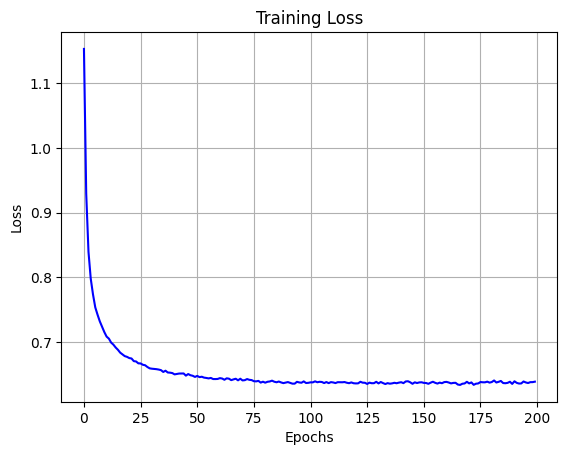

In [28]:
import matplotlib.pyplot as plt
print(train_loss)
plt.plot(train_loss,color="b")
plt.title("Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)

In [76]:
# 8. Evaluate Model
true, pred = evaluate_model(model, test_loader, device, le)


--- Starting Evaluation ---
Classification Accuracy: 72.49%

Sample Predictions:
['74:2f:68:81:69:42' '74:2f:68:81:69:42' '00:16:6c:ab:6b:88' ...
 '74:2f:68:81:69:42' '74:2f:68:81:69:42' '74:2f:68:81:69:42']
@@@@@@@@@@@@@
['74:2f:68:81:69:42' '74:2f:68:81:69:42' '74:2f:68:81:69:42' ...
 '74:2f:68:81:69:42' '74:2f:68:81:69:42' '74:2f:68:81:69:42']
@@@@@@@@@@@@@
                True MAC      Predicted MAC
0      74:2f:68:81:69:42  74:2f:68:81:69:42
1      74:2f:68:81:69:42  74:2f:68:81:69:42
2      00:16:6c:ab:6b:88  74:2f:68:81:69:42
3      08:21:ef:3b:fc:e3  74:2f:68:81:69:42
4      08:21:ef:3b:fc:e3  00:16:6c:ab:6b:88
...                  ...                ...
50991  74:2f:68:81:69:42  00:16:6c:ab:6b:88
50992  74:2f:68:81:69:42  74:2f:68:81:69:42
50993  74:2f:68:81:69:42  74:2f:68:81:69:42
50994  74:2f:68:81:69:42  74:2f:68:81:69:42
50995  74:2f:68:81:69:42  74:2f:68:81:69:42

[50996 rows x 2 columns]


In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [77]:
true
#cf = confusion_matrix(true,pred)
#type(confusion_matrix)

array(['74:2f:68:81:69:42', '74:2f:68:81:69:42', '00:16:6c:ab:6b:88', ...,
       '74:2f:68:81:69:42', '74:2f:68:81:69:42', '74:2f:68:81:69:42'],
      dtype=object)

In [92]:
pred

array(['74:2f:68:81:69:42', '74:2f:68:81:69:42', '74:2f:68:81:69:42', ...,
       '74:2f:68:81:69:42', '74:2f:68:81:69:42', '74:2f:68:81:69:42'],
      dtype=object)

In [80]:
len(np.unique(true))

25

In [98]:
from sklearn.metrics import f1_score

# Macro average (unweighted mean of F1 for each class)
f1_macro = f1_score(true, pred, average='macro')

# Weighted average (weighted by support/frequency of each class)
f1_weighted = f1_score(true, pred, average='weighted')

# Micro average (global calculation)
f1_micro = f1_score(true, pred, average='micro')

print(f"F1 Score (macro): {f1_macro:.4f}")
print(f"F1 Score (weighted): {f1_weighted:.4f}")
print(f"F1 Score (micro): {f1_micro:.4f}")

F1 Score (macro): 0.1854
F1 Score (weighted): 0.7038
F1 Score (micro): 0.7249


25   21


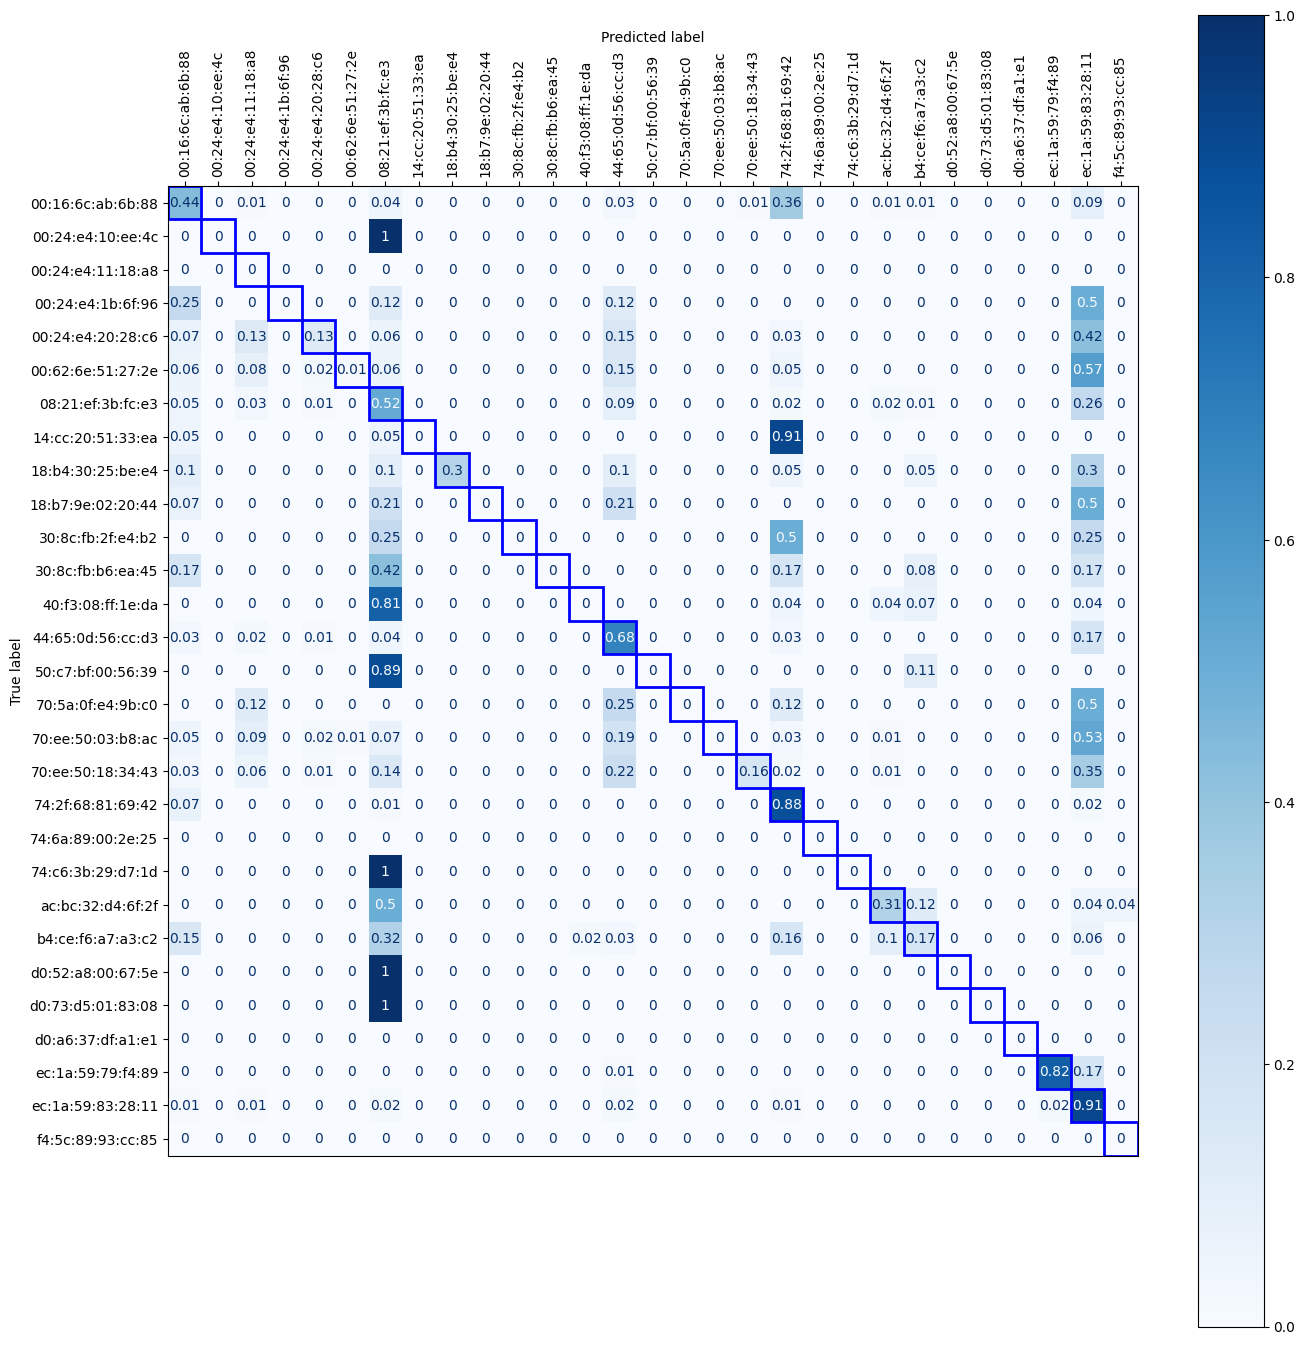

In [102]:
mapping = {}
'''with open("List_Of_Devices.txt",'r') as reader:
    next(reader)
    next(reader)
    for line in reader:
        elements = line.split()
        name, address = " ".join(elements[:-2]), elements[-2]
        #print(name, " ",address)
        mapping[address] = name

print(mapping)'''


labels = sorted(set(true)|set(pred))  # Union of all labels, sorted
print(len(set(true)), " ", len(set(pred)))
cf = confusion_matrix(true,pred,labels=labels,normalize='true')
cf_normalized = np.around(cf,decimals=2)
#cf_normalized= np.around(cf.astype('float') / cf.sum(axis=1)[:, np.newaxis], decimals=2) #normal normalized doesn't round, and .2f doesn't do it that way
#labels = set(pred)
#print(len(labels), " ", len(true))
cm_display = ConfusionMatrixDisplay(confusion_matrix = cf_normalized,display_labels=labels)

fig, ax = plt.subplots(figsize=(14, 14))
ax.tick_params(
    axis='x',         # Apply to the X-axis
    top=True,         # Show ticks at the top
    labeltop=True,    # Show labels at the top
    bottom=False,     # Hide ticks at the bottom
    labelbottom=False # Hide labels at the bottom
)
ax.xaxis.set_label_position('top')
cm_display.plot(ax=ax, xticks_rotation=90, cmap="Blues")
#box diagonals for better viewing
for i in range(len(labels)):
    ax.add_patch(plt.Rectangle((i-0.5,i-0.5),1,1,fill=False,edgecolor='blue',linewidth=2))
plt.tight_layout()
plt.show()